In [4]:
import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import json
import cftime
from cftime import DatetimeNoLeap
from scipy import stats
from scipy.interpolate import interp1d
import dask
from tqdm import tqdm
from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
%matplotlib inline


from utils import QACC_utils
#from utils.config import model, min_lat_arctic, max_lat_arctic, min_lat_tropics, max_lat_tropics, min_year_late_cent, max_year_late_cent

##### SETTINGS
model = 'UKESM1-0-LL'
#min_lat_arctic, max_lat_arctic = 66, 90
#min_lat_tropics, max_lat_tropics = -23, 23


regions = ['Arctic', 'Tropics']
lat_band_dict = {'Arctic':[66, 90],
                 'Tropics':[-23, 23]}

scenarios = ['ssp245', 'ARISE', 'ssp245_baseline']

experiment_dict = {'ssp245':'ssp245', 
                   'ARISE':'ARISE',
                   'ssp245_baseline':'ssp245'}

time_slice_dict = {'ssp245':['2050', '2069'], 
                   'ARISE':['2050', '2069'],
                   'ssp245_baseline':['2015', '2033']} # we take a 19 year baseline to avoid having to read in the historical runs for 2014

from utils.Utils import weighted_annual_resample, get_ds_from_ceda, spatial_mean

In [7]:
### sea ice

ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']

DS_ssp245_SI_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='siconca', members=ens_mems_arise_UK, 
                              table='SImon', grid='gr').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()
DS_ssp245_baseline_SI_UK = DS_ssp245_SI_UK.sel(time=slice(time_slice_dict['ssp245_baseline'][0], time_slice_dict['ssp245_baseline'][1])).mean('Ensemble_member')
DS_ssp245_SI_UK = DS_ssp245_SI_UK.sel(time=slice(time_slice_dict['ssp245'][0], time_slice_dict['ssp245'][1])).mean('Ensemble_member')

### get siconca for ARISE
paths_si = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/SImon/siconca/gr/*/')
ds_list_si = []
for path in paths_si:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_si.append(ds)
DS_ARISE_siconca = xr.concat(ds_list_si, dim='Ensemble_member').sel(time=slice(time_slice_dict['ARISE'][0], time_slice_dict['ARISE'][1])).mean('Ensemble_member').load()

DS_ARISE_siconca = DS_ARISE_siconca.groupby(DS_ARISE_siconca.time.dt.month).mean()
DS_ssp245_SI_UK = DS_ssp245_SI_UK.groupby(DS_ssp245_SI_UK.time.dt.month).mean()

In [8]:
DS_ARISE_siconca

<xarray.Dataset> Size: 1MB
Dimensions:     (latitude: 144, month: 12, bnds: 2, longitude: 192)
Coordinates:
    type        |S7 7B b'sea_ice'
  * latitude    (latitude) float64 1kB -89.38 -88.12 -86.88 ... 88.12 89.38
  * longitude   (longitude) float64 2kB 0.9375 2.812 4.688 ... 355.3 357.2 359.1
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: bnds
Data variables:
    lat_bounds  (month, latitude, bnds) float64 28kB -90.0 -88.75 ... 88.75 90.0
    lon_bounds  (month, longitude, bnds) float64 37kB 0.0 1.875 ... 358.1 360.0
    siconca     (month, latitude, longitude) float32 1MB nan nan ... 99.25 99.25

In [ ]:
### dummy plotting code - for claude to follow for each subplot

month_dict = {'Annual mean':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
              'DJF': [12, 1, 2],
              'MAM': [3, 4, 5],
              'JJA': [6, 7, 8],
              'SON': [9, 10, 11]}


fig, axes = plt.subplots(3, 3, figsize=(7, 10), subplot_kw={'projection': ccrs.NorthPolarStereo()})

extent = [-180, 180, 50, 90] 



data = delta_siconca.where(delta_siconca.month.isin(month_dict[season]), drop=True).mean('month')
cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['longitude'])
ax = axes.flatten()[i]
cont_SI = ax.contourf(cyclic_lons, data['latitude'], cyclic_data,
                    transform=ccrs.PlateCarree(),
                    levels=np.arange(0, 40, 5),
                    cmap='Blues_r',
                    extend='both')



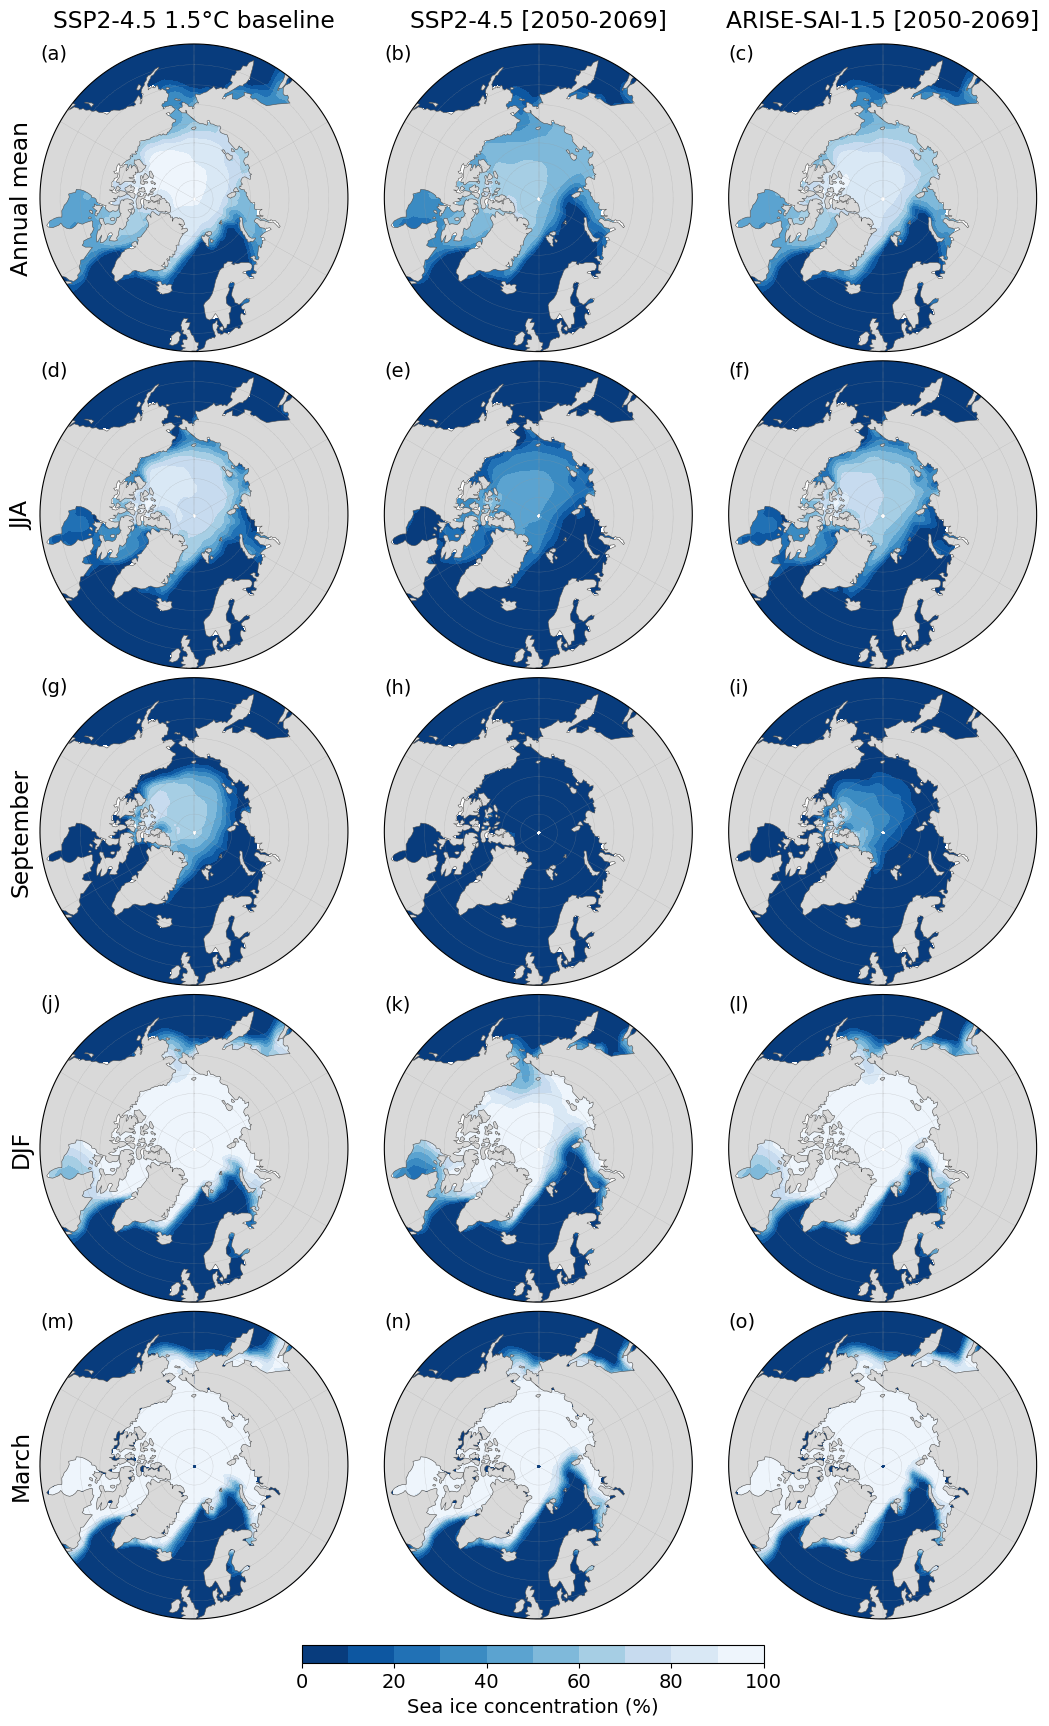

In [17]:
##### SEA ICE MAPS: absolute siconca, 5 periods x 3 scenarios

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.path as mpath

row_dict = {'Annual mean': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
            'JJA': [6, 7, 8],
            'September': [9],
            'DJF': [12, 1, 2],
            'March': [3]}

FS = 14
EXTENT = [-180, 180, 50, 90]
LEVELS = np.arange(0, 105, 10)


def to_monthly_clim(obj, var='siconca'):
    """Return a (month, lat, lon) DataArray whatever we're handed.
    DS_ssp245_baseline_SI_UK was never passed through the groupby('month')
    at the end of the loading cell, so it still carries a time dim."""
    da = obj[var] if isinstance(obj, xr.Dataset) else obj
    if 'month' in da.dims:
        return da
    return da.groupby(da['time'].dt.month).mean('time')


def period_mean(da, months):
    """UKESM1-0-LL is on a 360_day calendar (all months 30 days), so an
    unweighted mean over months is exact - no day-length weighting needed."""
    return da.sel(month=months).mean('month') if len(months) > 1 \
        else da.sel(month=months[0])


def polar_ax(ax):
    ax.set_extent(EXTENT, ccrs.PlateCarree())
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5
                        + [0.5, 0.5])
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=2)
    ax.coastlines(lw=0.4, color='0.3', zorder=3)
    ax.gridlines(lw=0.3, color='0.6', ls=':', zorder=4)


col_dict = {'SSP2-4.5 1.5°C baseline': to_monthly_clim(DS_ssp245_baseline_SI_UK),
            'SSP2-4.5 [2050-2069]': to_monthly_clim(DS_ssp245_SI_UK),
            'ARISE-SAI-1.5 [2050-2069]': to_monthly_clim(DS_ARISE_siconca)}

plt.rcParams.update({'font.size': FS})
fig, axes = plt.subplots(len(row_dict), len(col_dict), figsize=(11, 17.5),
                         subplot_kw={'projection': ccrs.NorthPolarStereo()})

panels = iter('abcdefghijklmno')
for i, (row_name, months) in enumerate(row_dict.items()):
    for j, (col_name, da) in enumerate(col_dict.items()):
        ax = axes[i, j]
        data = period_mean(da, months)
        cyc, cyc_lons = add_cyclic_point(data.values, coord=data['longitude'])
        cont = ax.contourf(cyc_lons, data['latitude'], cyc,
                           transform=ccrs.PlateCarree(),
                           levels=LEVELS, cmap='Blues_r', extend='neither',
                           zorder=1)
        polar_ax(ax)
        ax.text(0.0, 1.0, '({p})'.format(p=next(panels)),
                transform=ax.transAxes, va='top', ha='left',
                fontsize='medium', zorder=5)
        if i == 0:
            ax.set_title(col_name, fontsize='large', pad=12)
    axes[i, 0].text(-0.06, 0.5, row_name, transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize='large')

fig.subplots_adjust(left=0.05, right=0.98, top=0.955, bottom=0.055,
                    wspace=0.03, hspace=0.03)
cax = fig.add_axes([0.30, 0.030, 0.42, 0.010])
cb = fig.colorbar(cont, cax=cax, orientation='horizontal')
cb.set_label('Sea ice concentration (%)', fontsize='medium')
cb.set_ticks(np.arange(0, 101, 20))
cb.ax.tick_params(labelsize='medium')

#fig.suptitle('{m}: Arctic sea ice concentration'.format(m=model),
#             fontsize='large', y=0.985)
plt.savefig('figures/Sea_ice_concs_detailed.jpg', dpi=200)
plt.show()

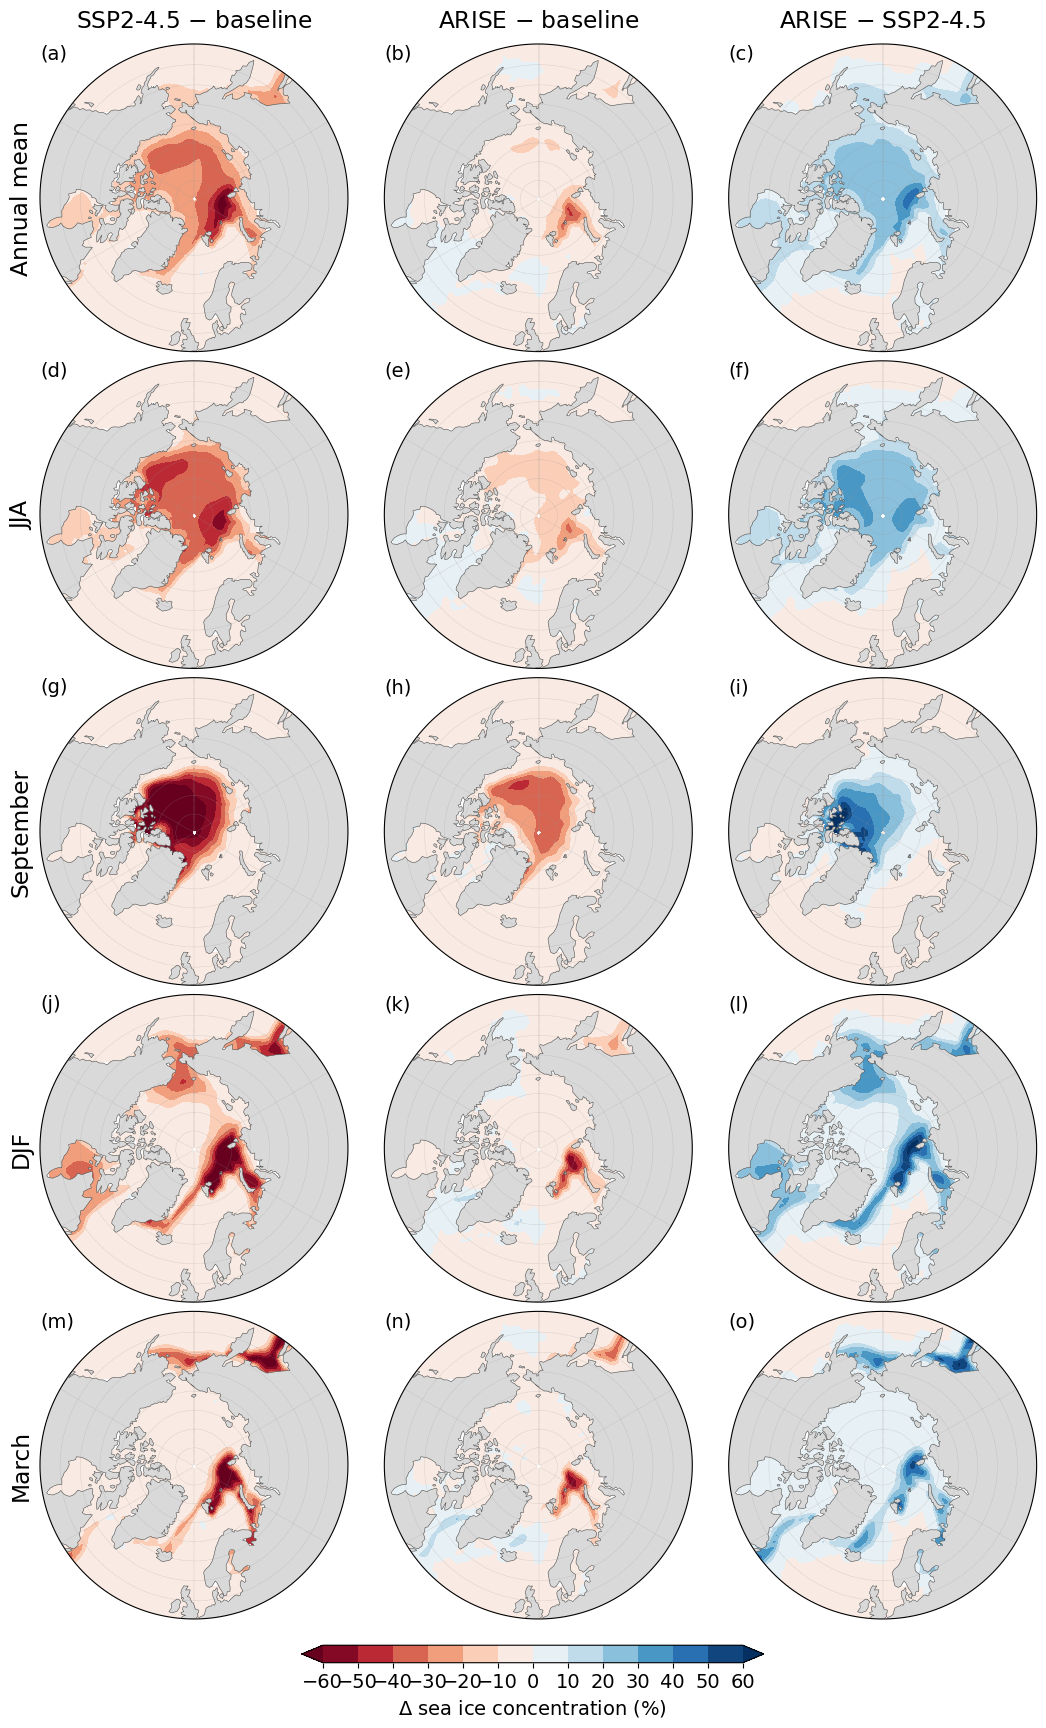

In [15]:
##### SEA ICE MAPS: siconca differences, 5 periods x 3 scenario pairs

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import matplotlib.path as mpath

row_dict = {'Annual mean': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
            'JJA': [6, 7, 8],
            'September': [9],
            'DJF': [12, 1, 2],
            'March': [3]}

FS = 14
EXTENT = [-180, 180, 50, 90]
DLEVELS = np.arange(-60, 65, 10)


def to_monthly_clim(obj, var='siconca'):
    """Return a (month, lat, lon) DataArray whatever we're handed.
    DS_ssp245_baseline_SI_UK was never passed through the groupby('month')
    at the end of the loading cell, so it still carries a time dim."""
    da = obj[var] if isinstance(obj, xr.Dataset) else obj
    if 'month' in da.dims:
        return da
    return da.groupby(da['time'].dt.month).mean('time')


def period_mean(da, months):
    """UKESM1-0-LL is on a 360_day calendar (all months 30 days), so an
    unweighted mean over months is exact - no day-length weighting needed."""
    return da.sel(month=months).mean('month') if len(months) > 1 \
        else da.sel(month=months[0])


def polar_ax(ax):
    ax.set_extent(EXTENT, ccrs.PlateCarree())
    theta = np.linspace(0, 2 * np.pi, 200)
    circle = mpath.Path(np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5
                        + [0.5, 0.5])
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.add_feature(cfeature.LAND, facecolor='0.85', zorder=2)
    ax.coastlines(lw=0.4, color='0.3', zorder=3)
    ax.gridlines(lw=0.3, color='0.6', ls=':', zorder=4)


base = to_monthly_clim(DS_ssp245_baseline_SI_UK)
ssp = to_monthly_clim(DS_ssp245_SI_UK)
arise = to_monthly_clim(DS_ARISE_siconca)

col_dict = {'SSP2-4.5 $-$ baseline': ssp - base,
            'ARISE $-$ baseline': arise - base,
            'ARISE $-$ SSP2-4.5': arise - ssp}

plt.rcParams.update({'font.size': FS})
fig, axes = plt.subplots(len(row_dict), len(col_dict), figsize=(11, 17.5),
                         subplot_kw={'projection': ccrs.NorthPolarStereo()})

panels = iter('abcdefghijklmno')
for i, (row_name, months) in enumerate(row_dict.items()):
    for j, (col_name, da) in enumerate(col_dict.items()):
        ax = axes[i, j]
        data = period_mean(da, months)
        cyc, cyc_lons = add_cyclic_point(data.values, coord=data['longitude'])
        cont = ax.contourf(cyc_lons, data['latitude'], cyc,
                           transform=ccrs.PlateCarree(),
                           levels=DLEVELS, cmap='RdBu', extend='both',
                           zorder=1)
        polar_ax(ax)
        ax.text(0.0, 1.0, '({p})'.format(p=next(panels)),
                transform=ax.transAxes, va='top', ha='left',
                fontsize='medium', zorder=5)
        if i == 0:
            ax.set_title(col_name, fontsize='large', pad=12)
    axes[i, 0].text(-0.06, 0.5, row_name, transform=axes[i, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize='large')

fig.subplots_adjust(left=0.05, right=0.98, top=0.955, bottom=0.055,
                    wspace=0.03, hspace=0.03)
cax = fig.add_axes([0.30, 0.030, 0.42, 0.010])
cb = fig.colorbar(cont, cax=cax, orientation='horizontal')
cb.set_label(r'$\Delta$ sea ice concentration (%)', fontsize='medium')
cb.set_ticks(np.arange(-60, 61, 10))
cb.ax.tick_params(labelsize='medium')

#fig.suptitle('{m}: Arctic sea ice concentration differences'.format(m=model),
#             fontsize='large', y=0.985)
plt.savefig('figures/Sea_ice_deltas_detailed.jpg', dpi=200)
plt.show()